In [1]:
## Imports
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys


from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))
from src.config import ANALYSIS_DIR, DATA_DIR, FIGURES_DIR


In [2]:
## Load data
d4_lapa = sc.read_h5ad(DATA_DIR / "egfDuod_D4_Lapa_DZ.h5ad")

In [3]:
## Identify our normalised and raw matrices
adata = d4_lapa
sc.settings.figdir = str(FIGURES_DIR / "qc/d4-lapa")


In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.leiden(adata, resolution=2, n_iterations = -1)
sc.tl.umap(adata)


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_66678/3867236213.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=2

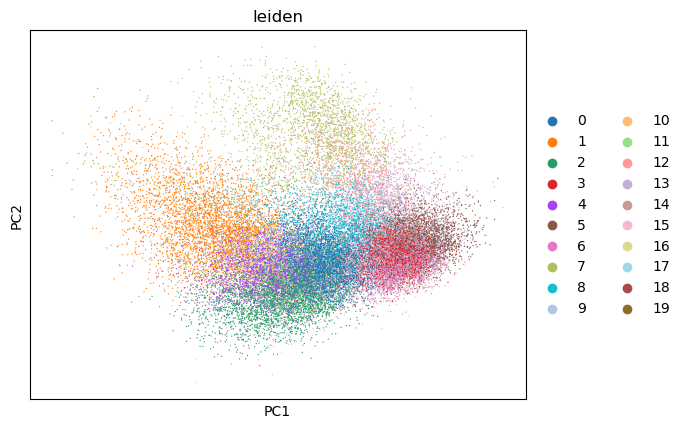

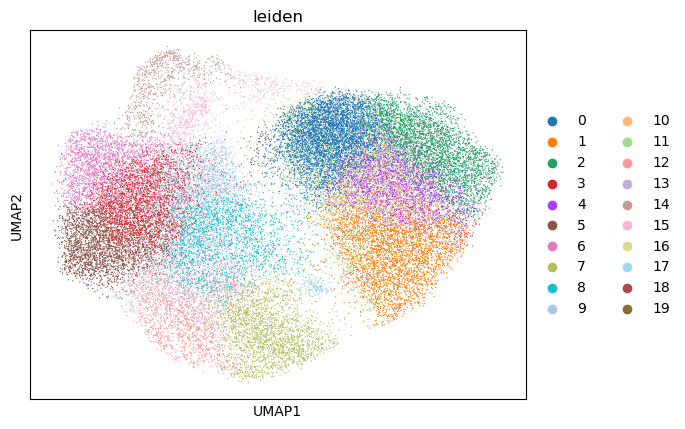

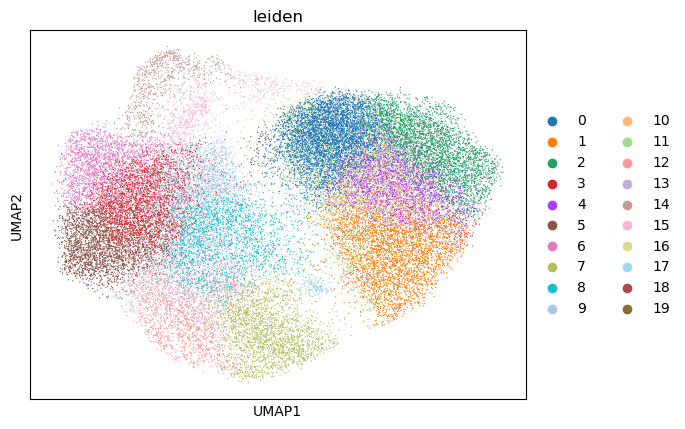

In [5]:


sc.pl.pca(adata, color="leiden")
sc.pl.umap(adata, color="leiden")

sc.pl.umap(adata, color="leiden", save="_g6_clustered.pdf")


In [6]:
#### This is much better
d4_lapa.obsm['X_pca'] = adata.obsm['X_pca']
d4_lapa.obsm['X_umap'] = adata.obsm['X_umap']
d4_lapa

d4_lapa.obs['leiden'] = adata.obs['leiden'].astype('category')
d4_lapa.obsp['distances'] = adata.obsp['distances']
d4_lapa.obsp['connectivities'] = adata.obsp['connectivities']

In [7]:
intermediate_directory = str(ANALYSIS_DIR)
sc.write(f'{intermediate_directory}/re_clustered_egfDuod_D4_Lapa_DZ.h5ad', d4_lapa)